In [21]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pickle
import joblib
import os
from imblearn.over_sampling import SMOTE

In [22]:
# data = combined, same as the regression model but with the binary label?
df_binary = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_train = df_binary[df_binary['Type'] == 'Train'].reset_index(drop=True)

df_train

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,170.00,Train,L,0.521953,-0.457762,-0.257788,-0.426305,1.304807,0.417798,...,1.616871,0.778243,-0.20324,3.472367,2.047792,2.116818,-0.562084,-0.133569,1.335854,0
1,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,296.85,Train,H,0.790196,0.502246,-0.865765,0.037682,2.292861,-0.759300,...,2.229837,2.356382,-0.20324,1.776268,2.047792,-0.586923,-0.562084,-0.133569,0.986054,1
2,Cc1cc(Br)c(cc1Br)C,73.00,Train,L,-1.394071,-1.455709,-0.865765,1.009138,-0.015188,2.162965,...,-0.692189,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.880351,0
3,OC(=O)c1ccc(c(c1)F)C,170.00,Train,L,0.783228,-0.407457,-0.561777,-0.769862,-0.827313,-0.231414,...,-0.725133,-0.775518,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.746893,0
4,OC(=O)C1CC(=O)c2c1cccc2,116.00,Train,L,1.037805,0.072266,-0.561777,-0.372483,0.412897,-0.623661,...,-0.386943,-0.146109,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.559748,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,N#CCC(=O)c1ccc(c(c1)Cl)Cl,116.00,Train,L,0.743032,-0.307410,-0.257788,0.811606,-0.080767,-0.174504,...,-0.677477,-0.775518,-0.20324,-0.906021,-0.488331,0.374209,-0.562084,-0.133569,-0.479979,0
12050,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,72.00,Train,L,-3.629431,-1.455709,8.253899,-1.180027,-0.407154,0.604831,...,2.908040,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,2.176568,0
12051,OC(=O)c1ccc2c(c1)CCCC2,155.50,Train,L,0.595646,-0.407457,-0.561777,-0.769862,-0.130908,-0.231340,...,-0.229073,0.910284,-0.20324,0.166894,-0.488331,-0.586923,-0.562084,-0.133569,-0.590538,0
12052,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,146.00,Train,L,-2.846540,0.100650,1.870134,0.457744,1.279393,0.388075,...,0.932824,-0.775518,-0.20324,0.423557,2.047792,4.876089,-0.562084,-0.133569,1.885874,0


In [23]:
from skopt.space import Real, Integer, Categorical # Added Categorical

def model_development_classifier(data, non_feature_cols, target_col, trials):
    # 1. Setup Features and Target
    X = data.drop(columns=non_feature_cols)
    y = data[target_col].values 

    # 2. Precompute Stratified Folds
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, y))

    # ── Helper: run 10-fold CV ─────────────────────
    def run_cv_f1(model_instance):
        fold_f1_scores = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            # Calculate F1 instead of LogLoss
            fold_f1_scores.append(f1_score(y_val, preds, average='weighted'))
            
        return fold_f1_scores

    default_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    base_model    = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

    # In the search_space dictionary inside model_development_classifier:
    search_space  = {
        'num_leaves': Integer(20, 300),
        'max_depth': Integer(3, 12),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'n_estimators': Integer(20, 500),
        'min_child_samples': Integer(10, 50),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.4, 1.0),
        'reg_alpha': Real(1e-5, 10.0, prior='log-uniform'),
        'reg_lambda': Real(1e-5, 10.0, prior='log-uniform'),
        'scale_pos_weight': Categorical([1.0]), # CHANGE THIS: Lock at 1.0 for SMOTE
}

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_losses_0 = run_cv_f1(default_model)
    mean_0 = float(np.mean(fold_losses_0))
    std_0  = float(np.std(fold_losses_0))

    # Change 'mean_logloss' to 'mean_score' and 'std_logloss' to 'std_score'
    trial_results[0] = {'mean_score': mean_0, 'std_score': std_0}
    # Fix the print label too (it's F1 now, not LogLoss)
    print(f"Trial  0 (default) | mean F1: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-N: BayesSearchCV ────────────────────────────────────
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=trials,
        cv=folds,
        scoring='f1_weighted', 
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    for i in range(trials):
        score = opt.cv_results_['mean_test_score'][i]
        std   = opt.cv_results_['std_test_score'][i] # Add this line
        trial_results[i + 1] = {
            'mean_score': score,
            'std_score':  std,    # Add this line
            'params': opt.cv_results_['params'][i]
        }
        print(f"Trial {i+1:>2d} | mean F1: {score:.4f} ± {std:.4f}")

    return trial_results, opt.best_estimator_

In [25]:
# 1. Setup paths and column names
data_prefix = "../0_data/processed_data/"
label = 'MP_label'
output = 'Binary'
model_type = "classifier_SMOTE" # This helps label your saved files
model_name = "LGB"
num_trials = 20

# Ensure non_features is a single flat list
non_features = ['SMILES', 'MP', 'Type', label, output]

# 1. Prepare your original X and y from the training data
X = df_train.drop(columns=non_features)
y = df_train[output]

# 2. Initialize SMOTE
# sampling_strategy='minority' ensures only the High-MP (1) class is boosted
sm = SMOTE(sampling_strategy='minority', random_state=42)

# 3. Create the oversampled training set
X_resampled, y_resampled = sm.fit_resample(X, y)

# 4. Check the new balance
print(f"Original High-MP count: {sum(y == 1)}")
print(f"New High-MP count:      {sum(y_resampled == 1)}")

Original High-MP count: 615
New High-MP count:      11439


In [26]:
# Reconstruct the dataframe for your function
df_smote = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name=output)], axis=1)

# Add dummy columns for non_features so the function doesn't crash
for col in non_features:
    if col not in df_smote.columns:
        df_smote[col] = "synthetic"

# Run the classifier
print("--- Running SMOTE Classifier ---")
results_smote, model_smote = model_development_classifier(
    data=df_smote, 
    non_feature_cols=non_features, 
    target_col=output, 
    trials=20
)

# 3. Save the Trial Results (Metrics per trial)
results_filename = f'model_development_results_{model_name}_{model_type}.pkl'
with open(results_filename, 'wb') as f:
    pickle.dump(results_smote, f)

# 4. Save the Best Model (The actual trained classifier)
model_filename = f"best_model_{model_name}_{model_type}.joblib"
joblib.dump(model_smote, model_filename, compress=3)

print(f"Successfully saved trial results to {results_filename}")
print(f"Successfully saved best model to {model_filename}")

--- Running SMOTE Classifier ---
Trial  0 (default) | mean F1: 0.9805 ± 0.0029
Trial  1 | mean F1: 0.9859 ± 0.0023
Trial  2 | mean F1: 0.9847 ± 0.0026
Trial  3 | mean F1: 0.9796 ± 0.0025
Trial  4 | mean F1: 0.9758 ± 0.0029
Trial  5 | mean F1: 0.9847 ± 0.0024
Trial  6 | mean F1: 0.9823 ± 0.0030
Trial  7 | mean F1: 0.9833 ± 0.0026
Trial  8 | mean F1: 0.9840 ± 0.0032
Trial  9 | mean F1: 0.9848 ± 0.0021
Trial 10 | mean F1: 0.9867 ± 0.0023
Trial 11 | mean F1: 0.9861 ± 0.0025
Trial 12 | mean F1: 0.9837 ± 0.0028
Trial 13 | mean F1: 0.9823 ± 0.0023
Trial 14 | mean F1: 0.9822 ± 0.0031
Trial 15 | mean F1: 0.8646 ± 0.0077
Trial 16 | mean F1: 0.9847 ± 0.0026
Trial 17 | mean F1: 0.9817 ± 0.0035
Trial 18 | mean F1: 0.9815 ± 0.0034
Trial 19 | mean F1: 0.9822 ± 0.0034
Trial 20 | mean F1: 0.9793 ± 0.0033
Successfully saved trial results to model_development_results_LGB_classifier_SMOTE.pkl
Successfully saved best model to best_model_LGB_classifier_SMOTE.joblib


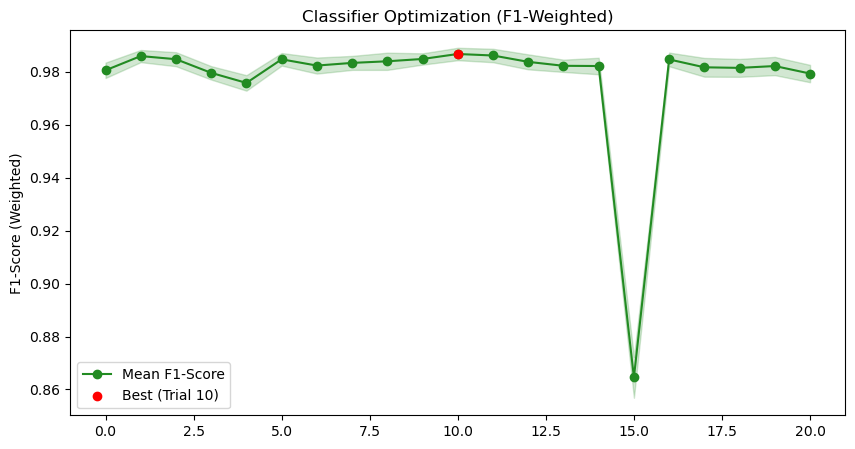

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_classifier_performance(results_dict):
    trials = sorted(results_dict.keys())
    means = [results_dict[t]['mean_score'] for t in trials]
    stds  = [results_dict[t]['std_score']  for t in trials]

    means, stds = np.array(means), np.array(stds)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(trials, means, marker='o', color='forestgreen', label='Mean F1-Score')
    ax.fill_between(trials, means - stds, means + stds, alpha=0.2, color='forestgreen')
    
    best_trial = trials[np.argmax(means)] # argmax because higher F1 is better
    best_f1 = np.max(means)
    
    ax.scatter([best_trial], [best_f1], color='red', zorder=5, label=f'Best (Trial {best_trial})')
    ax.set_ylabel('F1-Score (Weighted)')
    ax.set_title('Classifier Optimization (F1-Weighted)')
    ax.legend()
    plt.show()

plot_classifier_performance(results_smote)

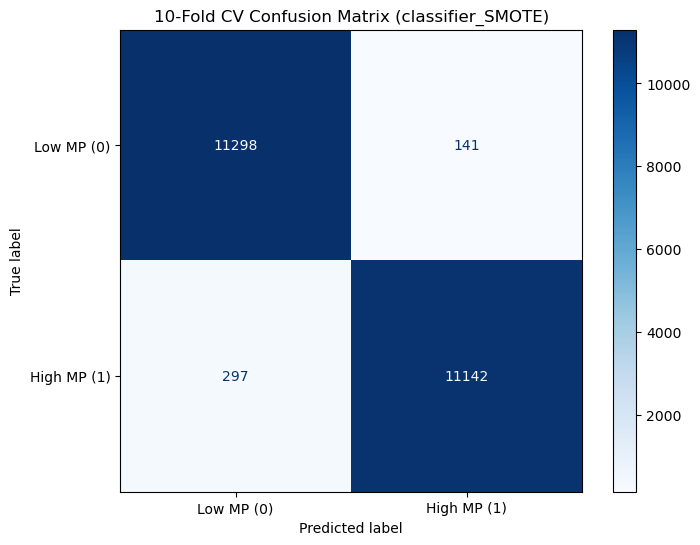

In [34]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate 'Out-of-Fold' predictions for the entire training set
# This uses the best hyperparameters found but ensures each prediction
# is made by a model that didn't see that specific data point during training.
X = df_smote.drop(columns=non_features)
y = df_smote[output]

y_pred_cv = cross_val_predict(model_smote, X, y, cv=10)

# 2. Compute the matrix
cm = confusion_matrix(y, y_pred_cv)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low MP (0)', 'High MP (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'10-Fold CV Confusion Matrix ({model_type})')
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Calculate individual metrics
accuracy  = accuracy_score(y, y_pred_cv)
precision = precision_score(y, y_pred_cv) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y, y_pred_cv)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y, y_pred_cv)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 3. Print the full report for both classes
print("Full Classification Report:")
print(classification_report(y, y_pred_cv, target_names=['Low MP', 'High MP']))

--- Performance Metrics: classifier_SMOTE Strategy ---
Accuracy:  0.9809
Precision: 0.9875 (When model says 'High', how often is it right?)
Recall:    0.9740 (How many 'High' compounds did we catch?)
F1-Score:  0.9807
---------------------------------------------
Full Classification Report:
              precision    recall  f1-score   support

      Low MP       0.97      0.99      0.98     11439
     High MP       0.99      0.97      0.98     11439

    accuracy                           0.98     22878
   macro avg       0.98      0.98      0.98     22878
weighted avg       0.98      0.98      0.98     22878



TEST SET EVALUATION

In [36]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_test = df[df['Type'] == 'Test'].reset_index(drop=True)

df_test

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,0.667614,-0.775518,-0.20324,0.531278,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,0
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,0.304196,1.986153,-0.20324,0.023628,-0.488331,0.374209,-0.562084,-0.133569,0.908283,0
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.744034,-0.775518,-0.20324,0.107665,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,0
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,0.233292,0.696792,-0.20324,2.241899,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,0
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.880423,-0.775518,-0.20324,-0.425651,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.004857,0.083653,-0.20324,0.187604,-0.488331,0.323579,1.779092,-0.133569,0.084641,0
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,1.017151,-0.775518,-0.20324,0.023628,-0.488331,3.044038,-0.562084,-0.133569,0.268670,0
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.665594,0.035283,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,0
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,-0.462402,1.326200,-0.20324,-0.906021,2.047792,-0.586923,1.779092,-0.133569,-0.346521,0


In [32]:
# 1. Prepare the test features (X_test) and actual labels (y_test)
X_test = df_test.drop(columns=non_features)
y_test = df_test[output]

# 2. Use the single "Best Model" to make predictions
y_pred_test = model_smote.predict(X_test)

# 3. Get the probabilities (useful for confidence analysis)
y_prob_test = model_smote.predict_proba(X_test)[:, 1]

print("Predictions completed on the test set.")

Predictions completed on the test set.


--- Performance Metrics: classifier_SMOTE Strategy ---
Accuracy:  0.9537
Precision: 0.5750 (When model says 'High', how often is it right?)
Recall:    0.3498 (How many 'High' compounds did we catch?)
F1-Score:  0.4350
---------------------------------------------
--- Final Test Results: classifier_SMOTE Strategy ---
              precision    recall  f1-score   support

      Low MP       0.97      0.99      0.98      4903
     High MP       0.57      0.35      0.43       263

    accuracy                           0.95      5166
   macro avg       0.77      0.67      0.71      5166
weighted avg       0.95      0.95      0.95      5166



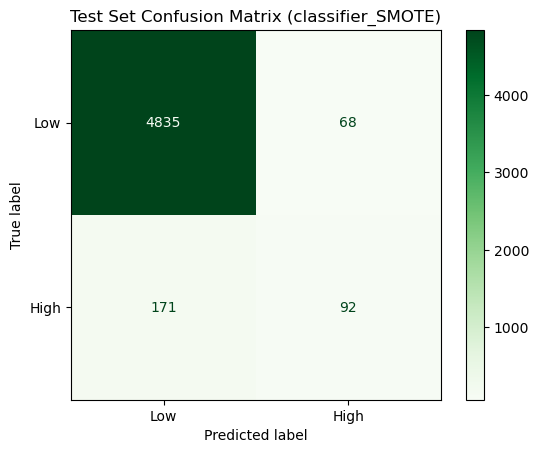

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Calculate individual metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y_test, y_pred_test)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y_test, y_pred_test)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 1. The Text Report
print(f"--- Final Test Results: {model_type} Strategy ---")
print(classification_report(y_test, y_pred_test, target_names=['Low MP', 'High MP']))

# 2. The Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Low', 'High'])
disp.plot(cmap='Greens')
plt.title(f'Test Set Confusion Matrix ({model_type})')
plt.show()